## Supervised Learning Project - Tree Methods Focus

### Import Required Libraries

In [1]:
# Importing important libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the dataset and checking the first 5 rows
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Checking the info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [4]:
# Checking the statistical summary of the dataset
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


### Exploratory Data Analysis

In [5]:
# Checking the number of missing values in each column
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

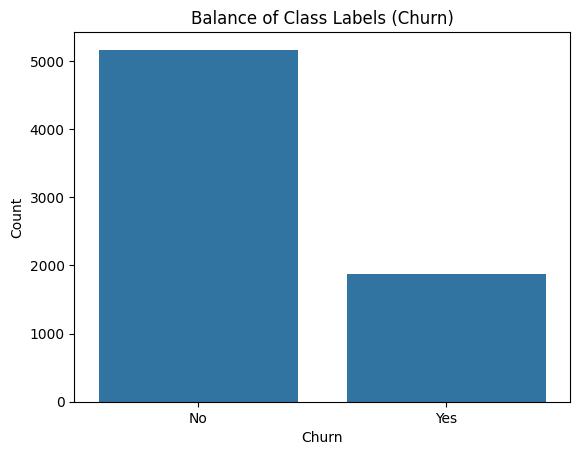

In [6]:
# Display the balance of the class labels (Churn) with a Count Plot.
sns.countplot(x='Churn', data=df)
plt.title("Balance of Class Labels (Churn)")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

/var/folders/3m/js66k40s0h7dlwq3dhmrr12m0000gq/T/ipykernel_67826/3117444661.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Churn", y="TotalCharges", data=df, palette="Set1")


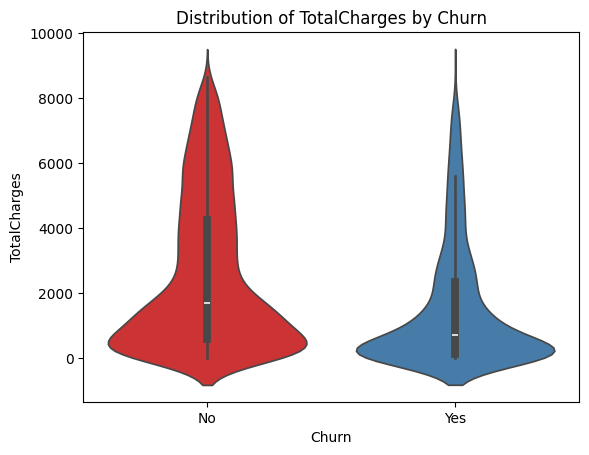

In [8]:
# Explore the distrbution of TotalCharges between Churn categories with a Box Plot or Violin Plot.
sns.violinplot(x="Churn", y="TotalCharges", data=df, palette="Set1")
plt.title("Distribution of TotalCharges by Churn")
plt.xlabel("Churn")
plt.ylabel("TotalCharges")
plt.show()

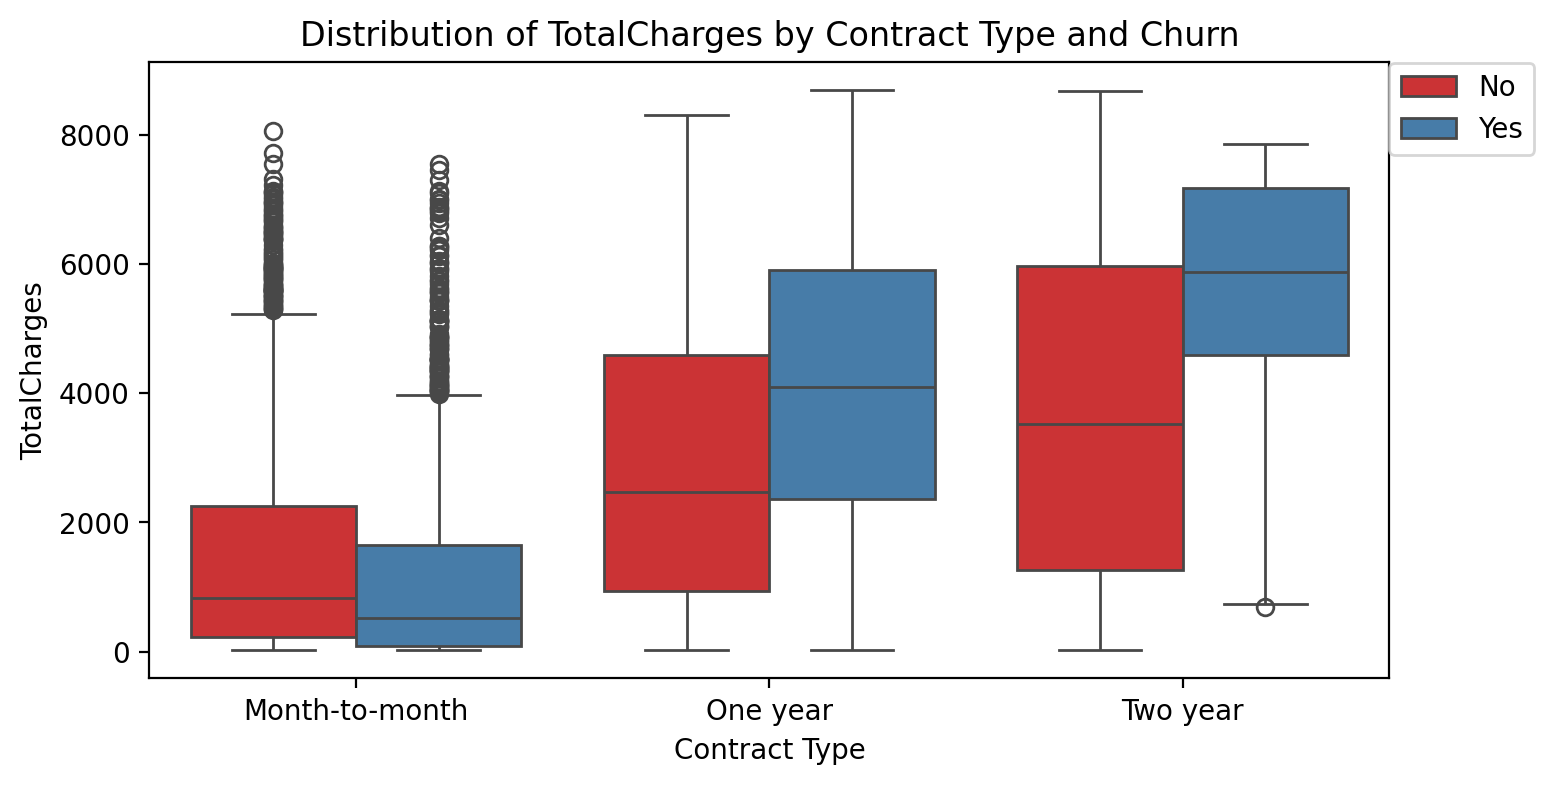

In [9]:
# Create a boxplot showing the distribution of TotalCharges per Contract type, also add in a hue coloring based on the Churn class.

plt.figure(figsize=(8,4), dpi=200)
sns.boxplot(x="Contract", y="TotalCharges", hue="Churn", data=df, palette="Set1")
plt.title("Distribution of TotalCharges by Contract Type and Churn")
plt.xlabel("Contract Type")
plt.ylabel("TotalCharges")
plt.legend(loc=(1,0.85))
plt.show()

In [10]:
# Checking the column names of the dataset
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
# Convert categorical columns into numerical dummy variables (one-hot encoding)
corr_df = pd.get_dummies(df[['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
                            'PhoneService', 'MultipleLines', 'InternetService',
                            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                            'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
                            'PaymentMethod', 'Churn']]).corr()

In [12]:
# Display the correlation of all the features with the target variable 'Churn_Yes' and sort them in ascending order, 
# also remove the first and last value as they will be 1 and 0 respectively.
corr_df['Churn_Yes'].sort_values().iloc[1:-1]

Contract_Two year                         -0.301552
StreamingMovies_No internet service       -0.227578
StreamingTV_No internet service           -0.227578
TechSupport_No internet service           -0.227578
DeviceProtection_No internet service      -0.227578
OnlineBackup_No internet service          -0.227578
OnlineSecurity_No internet service        -0.227578
InternetService_No                        -0.227578
PaperlessBilling_No                       -0.191454
Contract_One year                         -0.178225
OnlineSecurity_Yes                        -0.171270
TechSupport_Yes                           -0.164716
Dependents_Yes                            -0.163128
Partner_Yes                               -0.149982
PaymentMethod_Credit card (automatic)     -0.134687
InternetService_DSL                       -0.124141
PaymentMethod_Bank transfer (automatic)   -0.118136
PaymentMethod_Mailed check                -0.090773
OnlineBackup_Yes                          -0.082307
DeviceProtec

/var/folders/3m/js66k40s0h7dlwq3dhmrr12m0000gq/T/ipykernel_67826/3350928284.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_df['Churn_Yes'].sort_values().iloc[1:-1].index, y=corr_df['Churn_Yes'].sort_values().iloc[1:-1].values, palette="Set1")


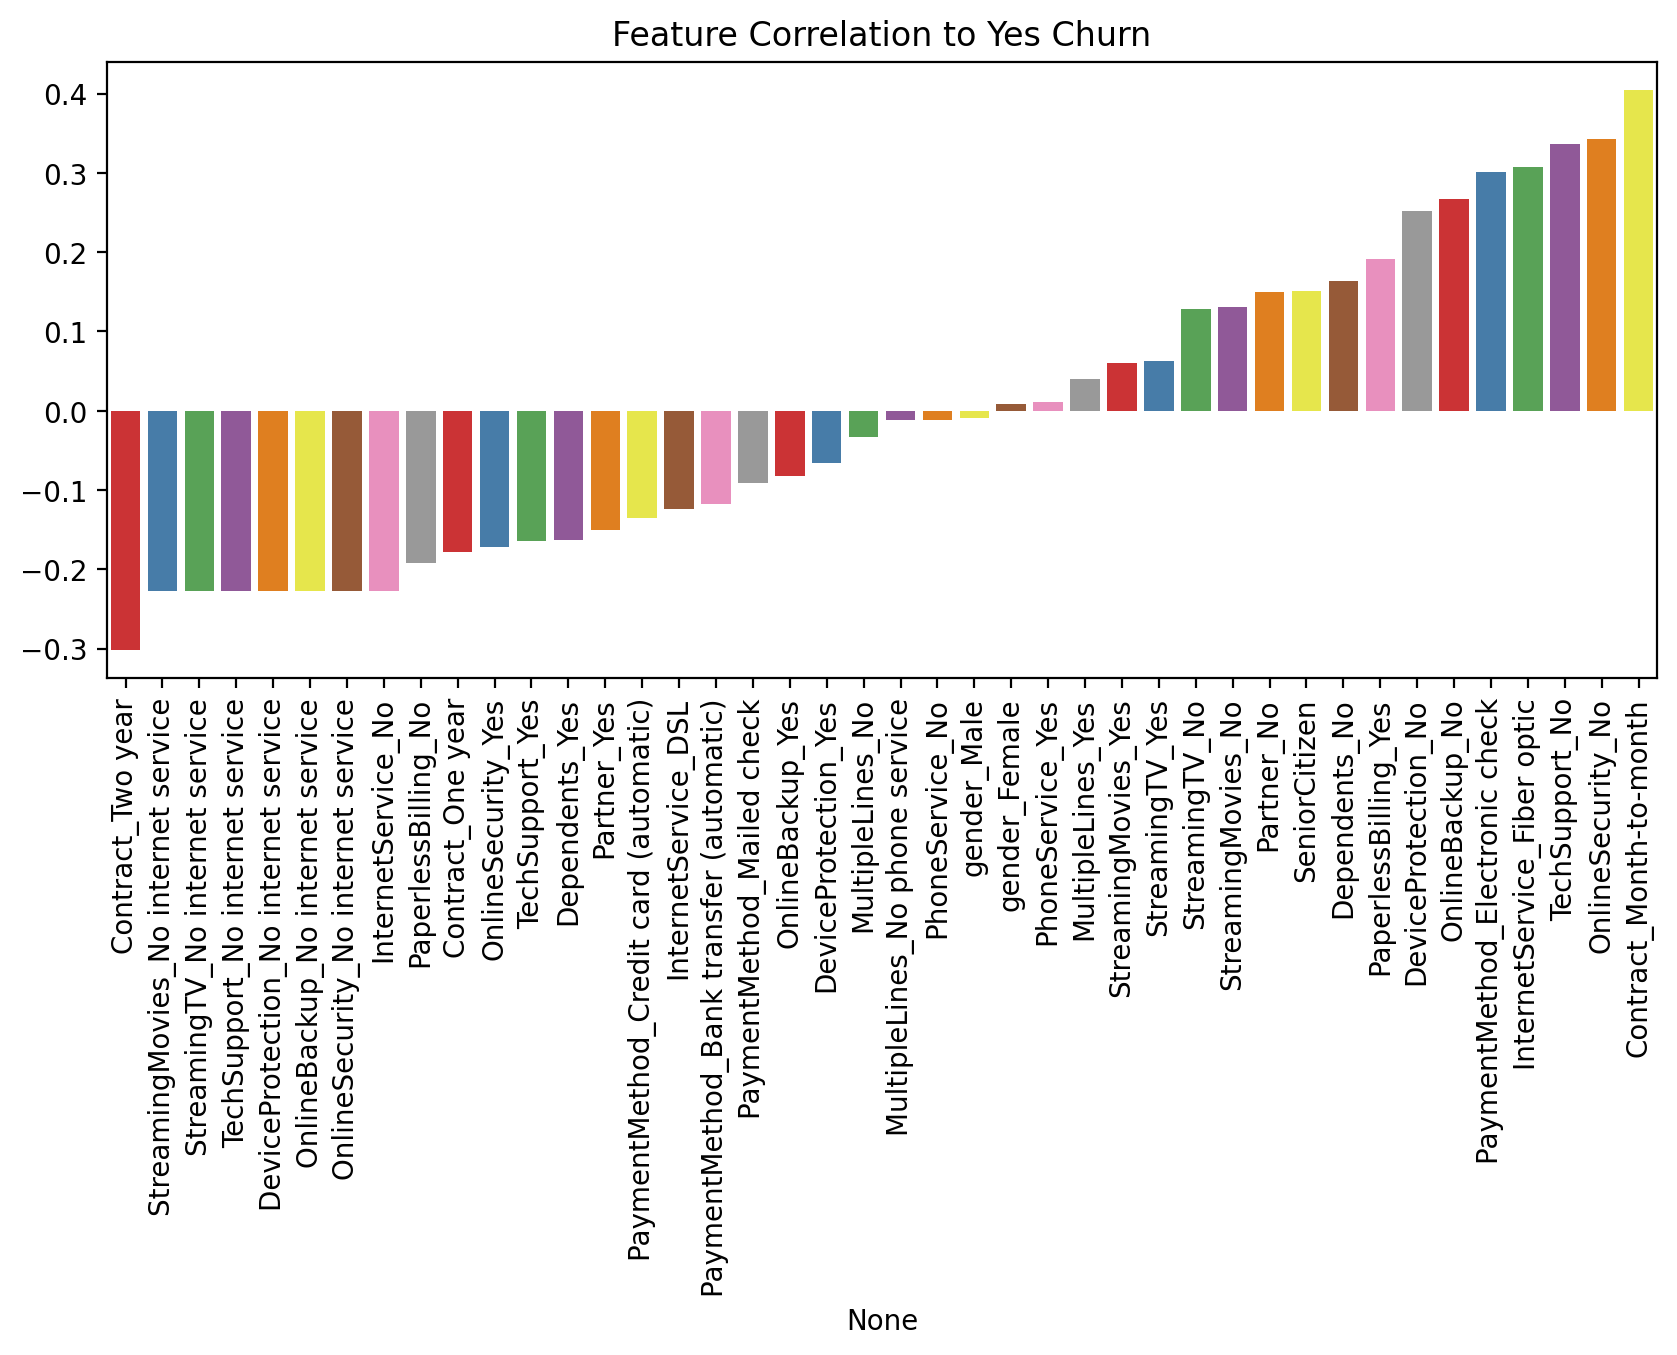

In [16]:
# Plot the correlation of all the features with the target variable 'Churn_Yes' and sort them in ascending order,
# also remove the first and last value as they will be 1 and 0 respectively.
plt.figure(figsize=(10,4),dpi=200)
sns.barplot(x=corr_df['Churn_Yes'].sort_values().iloc[1:-1].index, y=corr_df['Churn_Yes'].sort_values().iloc[1:-1].values, palette="Set1")
plt.title("Feature Correlation to Yes Churn")
plt.xticks(rotation=90)
plt.show()

### Churn Analysis

In [18]:
# What are the contract types available?
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

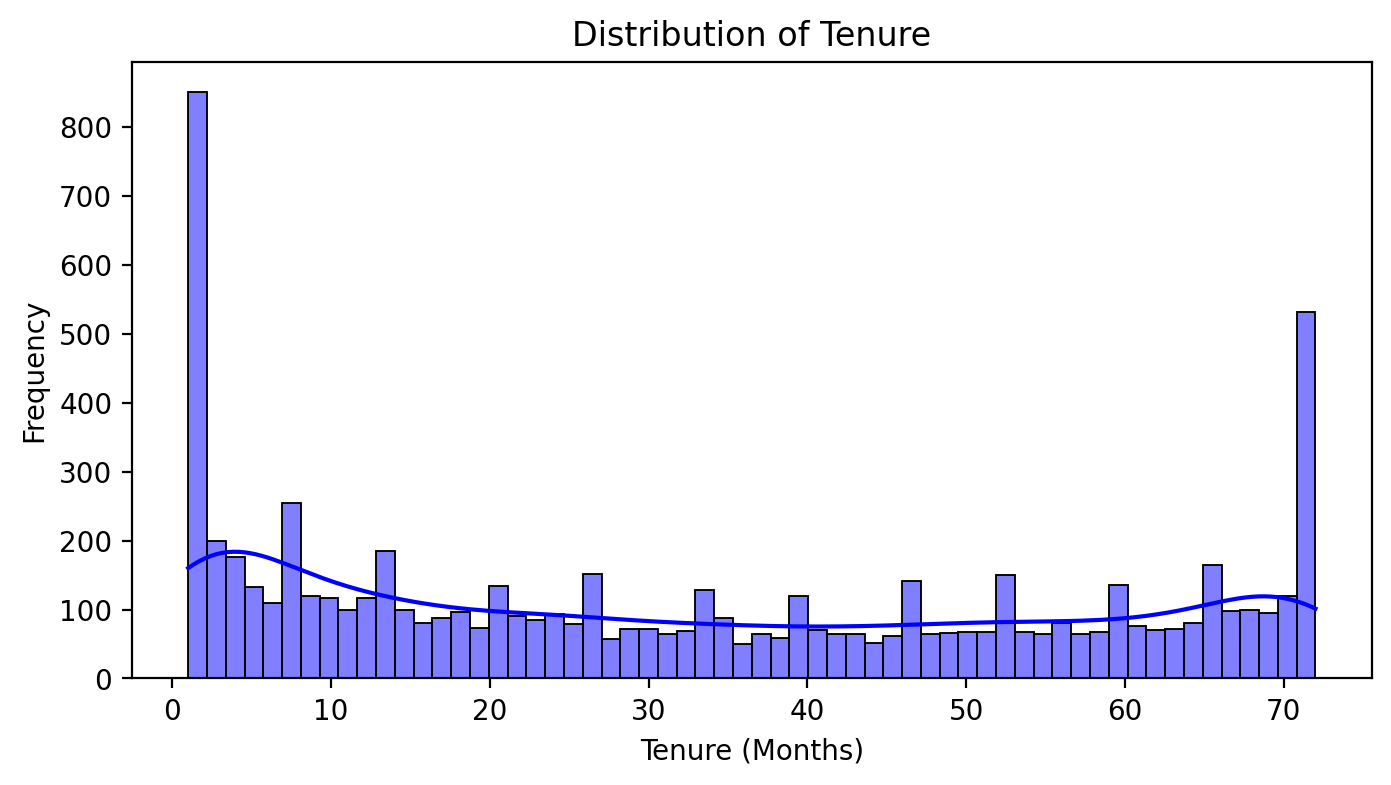

In [21]:
# Create a histogram displaying the distribution of 'tenure' column, which is the amount of months a customer was or has been on a customer.
plt.figure(figsize=(8,4), dpi=200)
sns.histplot(df['tenure'], bins=60, kde=True, color='blue')
plt.title("Distribution of Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")
plt.show()

<Figure size 1200x400 with 0 Axes>

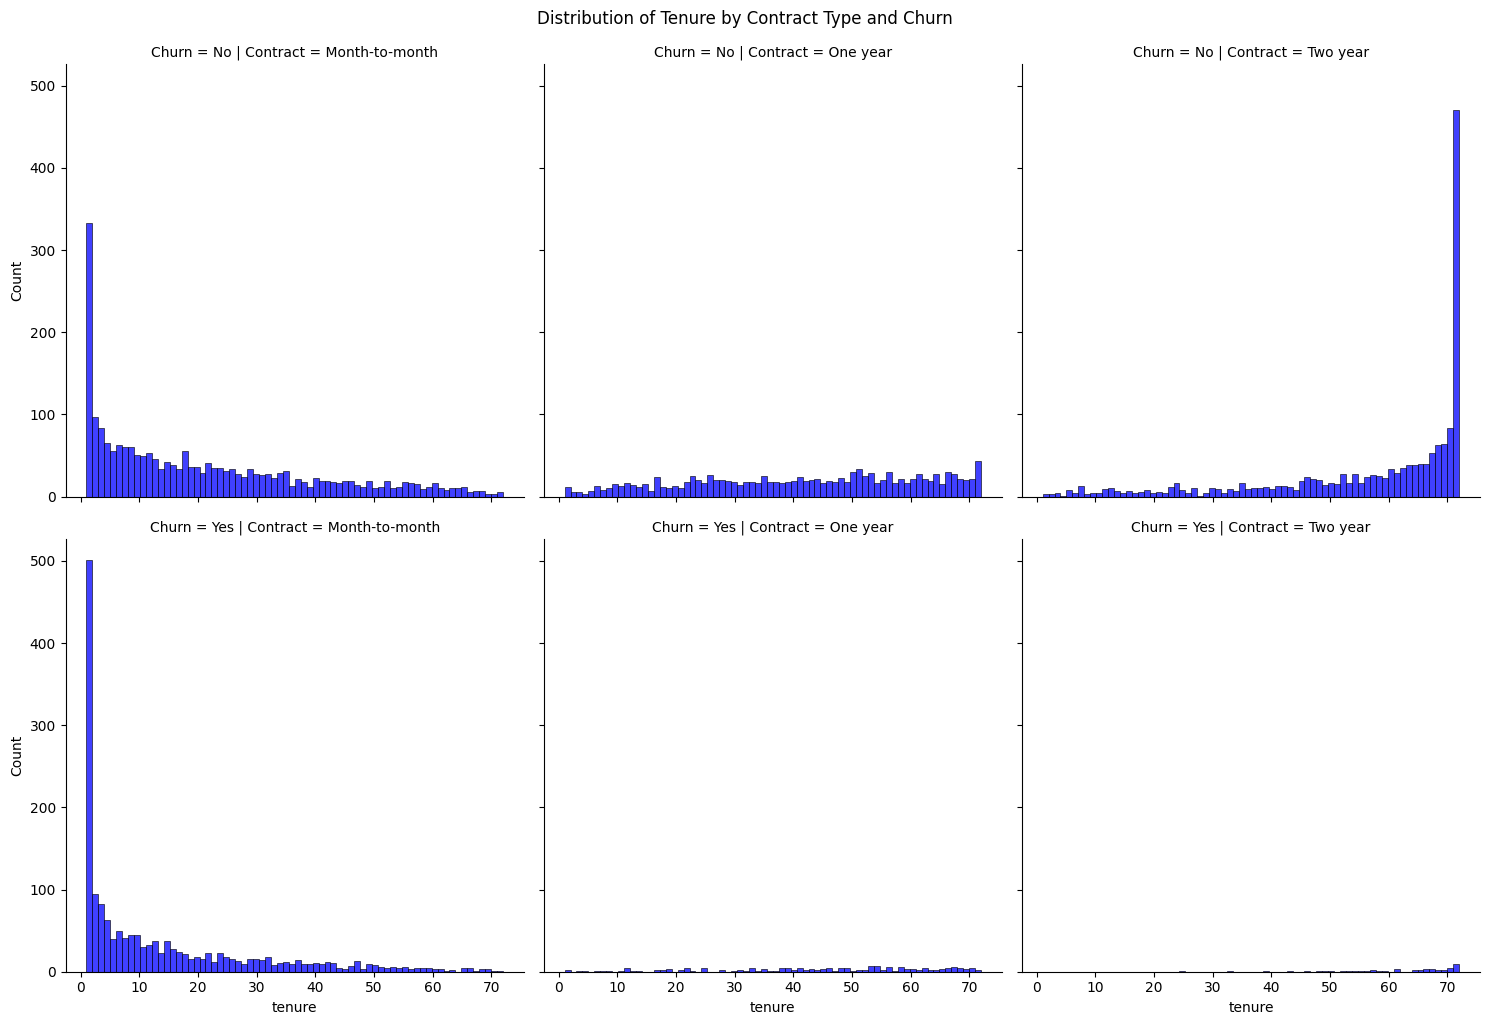

In [25]:
# Now use the seaborn documentation as a guide to create histograms separated by two additional features, Churn and Contract.
plt.figure(figsize=(6,2),dpi=200)
sns.displot(data=df,x='tenure',bins=70,col='Contract',row='Churn', color='blue')
plt.suptitle("Distribution of Tenure by Contract Type and Churn", y=1.02)
plt.show()

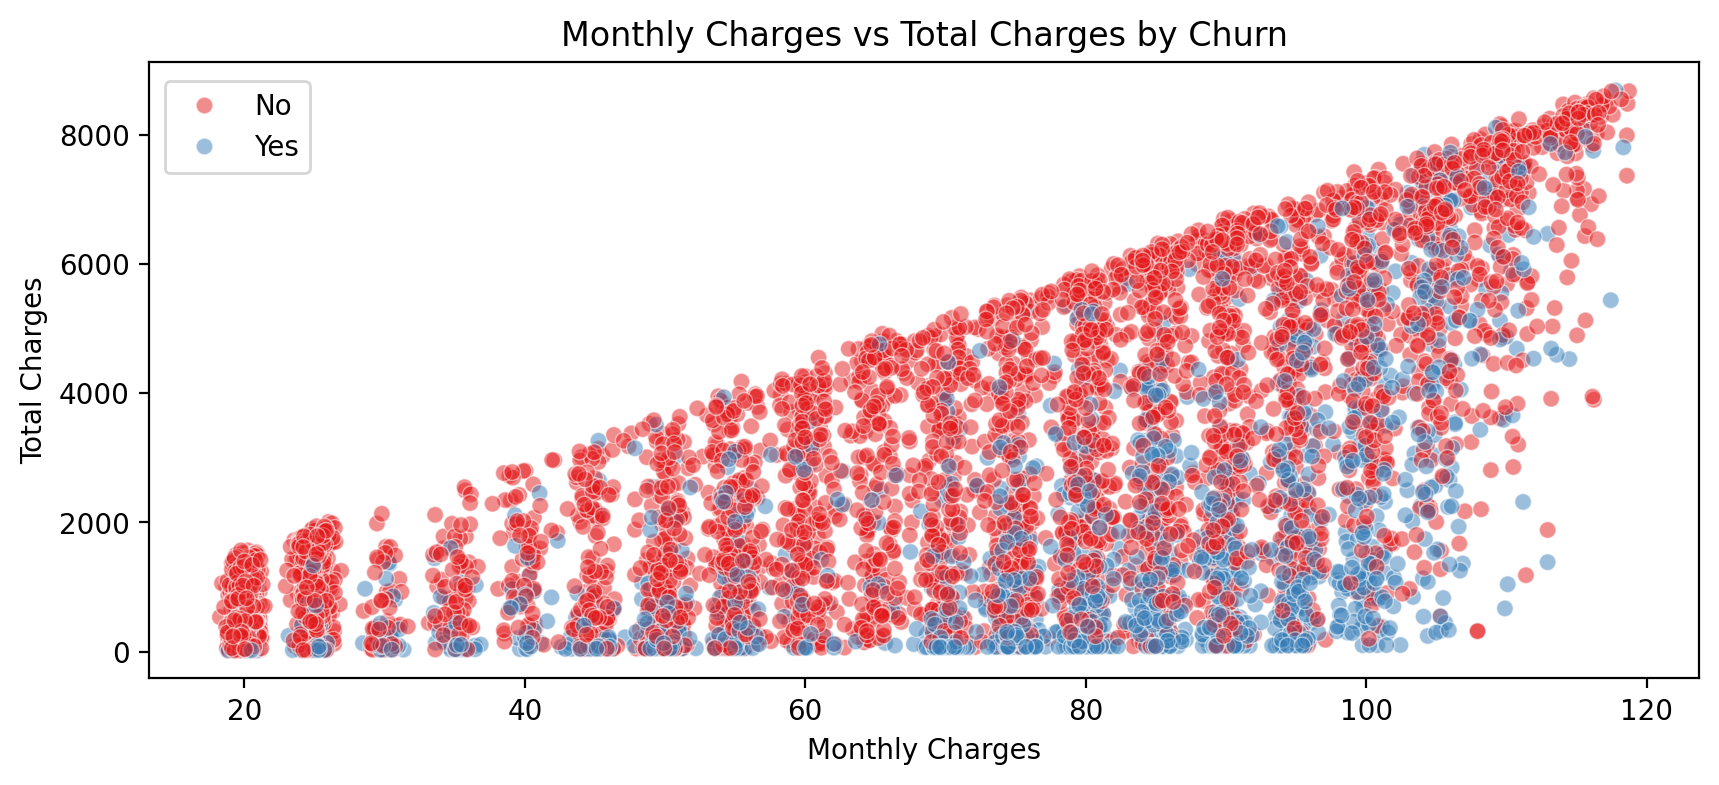

In [ ]:
# Create a scatter plot showing the relationship between MonthlyCharges and TotalCharges, also add in a hue coloring based on the Churn class.
plt.figure(figsize=(10,4), dpi=200)
sns.scatterplot(data=df, x="MonthlyCharges", y="TotalCharges", hue="Churn", palette="Set1", alpha=0.5, linewidth=0.5)
plt.title("Monthly Charges vs Total Charges by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.legend(loc=(0.01,0.82))
plt.show()

### Creating Cohorts based on Tenure

Analyze churn behavior by grouping customers into cohorts based on their tenure. For each tenure group (from 1 to 72 months), determine the percentage of customers who have churned (i.e., Churn = "Yes"). For instance, customers with a tenure of 1 month exhibit a churn rate of 61.99%. Observing these cohorts reveals a general pattern: as tenure increases, the churn rate tends to decrease, suggesting that customers who stay longer are less likely to discontinue the service.

In [41]:
# Count the number of churned ("Yes", "No") customers for each tenure group and store the results in two separate variables, no_churn and yes_churn.
no_churn = df.groupby(['Churn','tenure']).count().transpose()['No']
yes_churn = df.groupby(['Churn','tenure']).count().transpose()['Yes']

In [42]:
# Calculate the churn rate for each tenure group and store the results in a variable called churn_rate.
churn_rate = 100 * yes_churn / (no_churn+yes_churn)

In [ ]:
churn_rate.transpose()['customerID']

tenure
1     61.990212
2     51.680672
3     47.000000
4     47.159091
5     48.120301
        ...    
68     9.000000
69     8.421053
70     9.243697
71     3.529412
72     1.657459
Name: customerID, Length: 72, dtype: float64

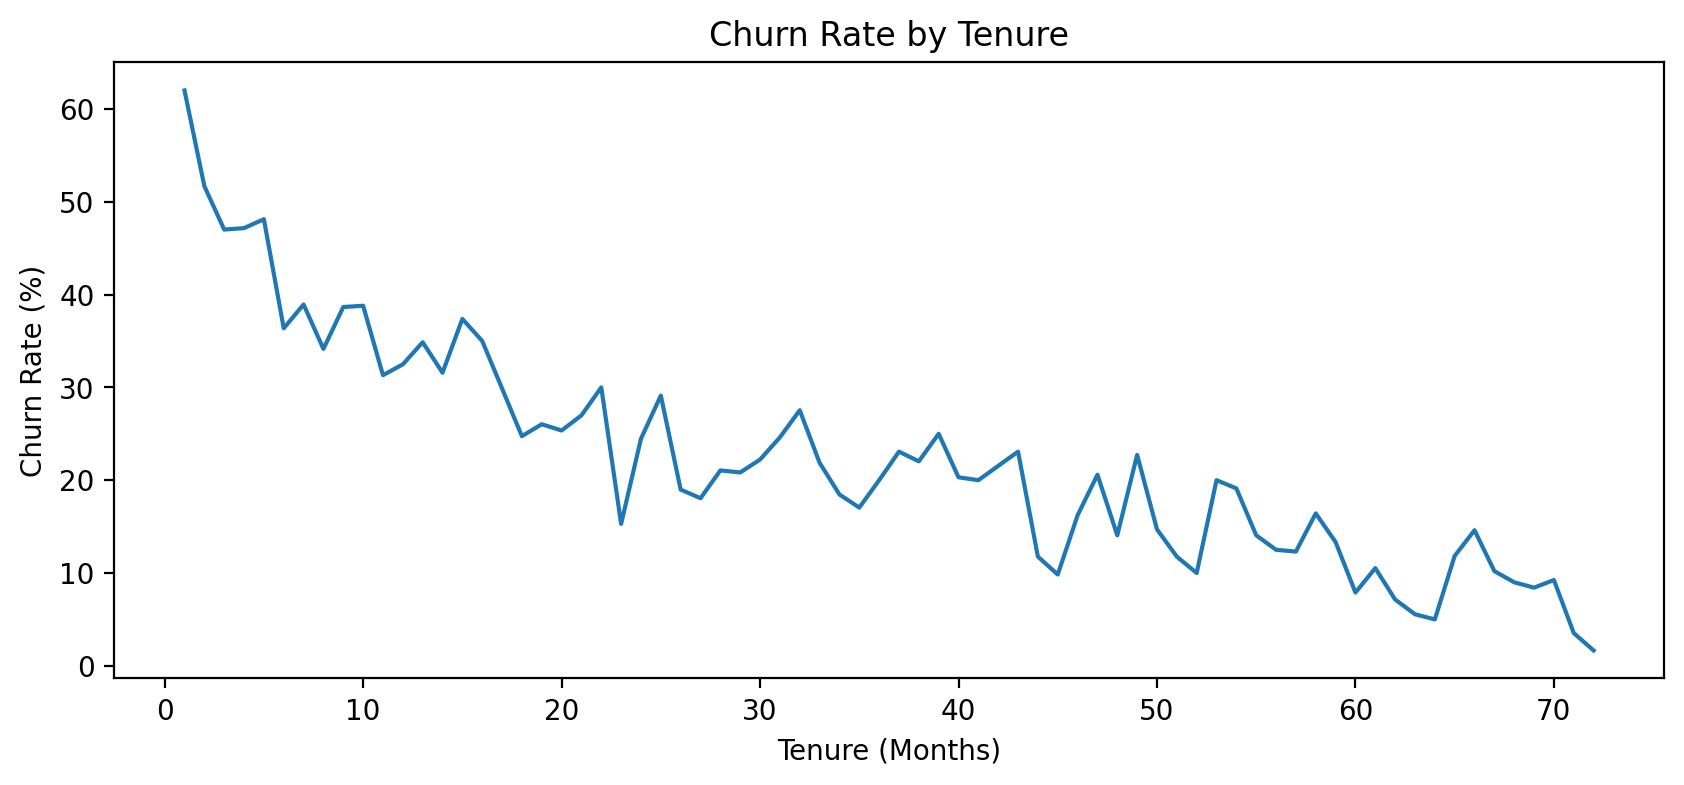

In [44]:
# Plot the churn rate by tenure.
plt.figure(figsize=(10,4), dpi=200)
churn_rate.iloc[0].plot()
plt.title("Churn Rate by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate (%)")
plt.show()

### Broader Cohort Groups
**Based on the tenure column values, create a new column called Tenure Cohort that creates 4 separate categories:**
   * '0-12 Months'
   * '24-48 Months'
   * '12-24 Months'
   * 'Over 48 Months' 

In [45]:
# Create a function that takes in the tenure of a customer and returns the cohort group they belong to based on the following criteria:

def cohort(tenure):
    if tenure < 13:
        return '0-12 Months'
    elif tenure < 25:
        return '12-24 Months'
    elif tenure < 49:
        return '24-48 Months'
    else:
        return "Over 48 Months"

In [46]:
# Create a new column in the dataframe called 'Tenure Cohort' that applies the cohort function to the 'tenure' column.

df['Tenure Cohort'] = df['tenure'].apply(cohort)

In [47]:
# Display the first 10 rows of the dataframe with the 'tenure' and 'Tenure Cohort' columns.
df.head(10)[['tenure','Tenure Cohort']]

,tenure,Tenure Cohort
0,1,0-12 Months
1,34,24-48 Months
2,2,0-12 Months
3,45,24-48 Months
4,2,0-12 Months
5,8,0-12 Months
6,22,12-24 Months
7,10,0-12 Months
8,28,24-48 Months
9,62,Over 48 Months


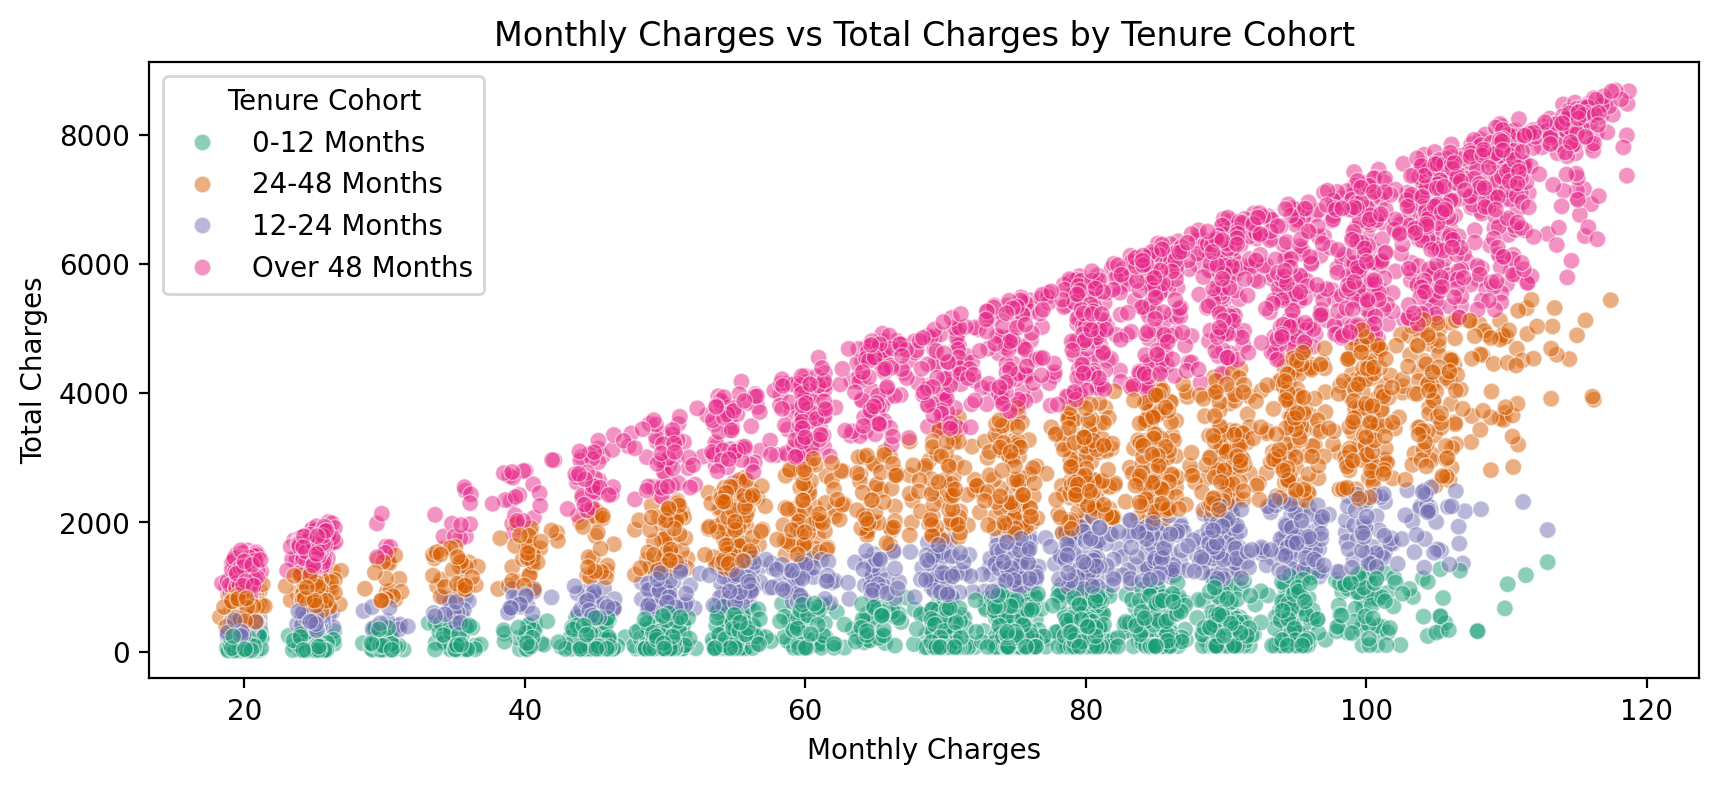

In [52]:
# Create a scatter plot showing the relationship between MonthlyCharges and TotalCharges, also add in a hue coloring based on the Tenure Cohort class.

plt.figure(figsize=(10,4), dpi=200)
sns.scatterplot(data=df, x="MonthlyCharges", y="TotalCharges", hue="Tenure Cohort", palette="Dark2", alpha=0.5, linewidth=0.5)
plt.title("Monthly Charges vs Total Charges by Tenure Cohort")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.show()

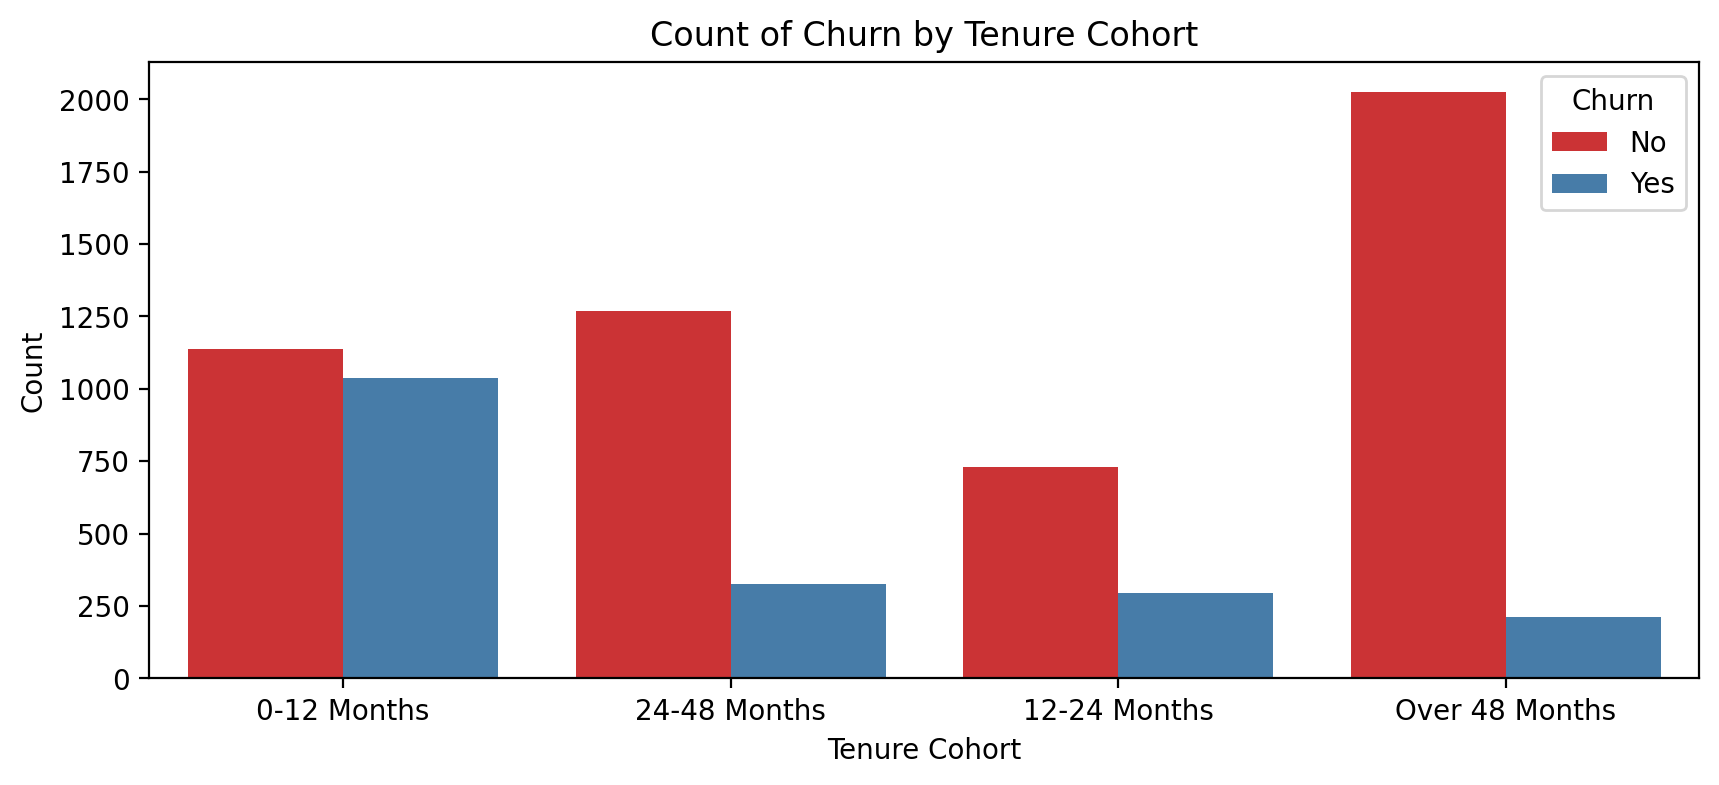

In [54]:
# Create a count plot showing the count of churned customers by Tenure Cohort, also add in a hue coloring based on the Churn class.

plt.figure(figsize=(10,4), dpi=200)
sns.countplot(data=df, x="Tenure Cohort", hue="Churn", palette="Set1")
plt.title("Count of Churn by Tenure Cohort")
plt.xlabel("Tenure Cohort")
plt.ylabel("Count")
plt.show()

<Figure size 2000x800 with 0 Axes>

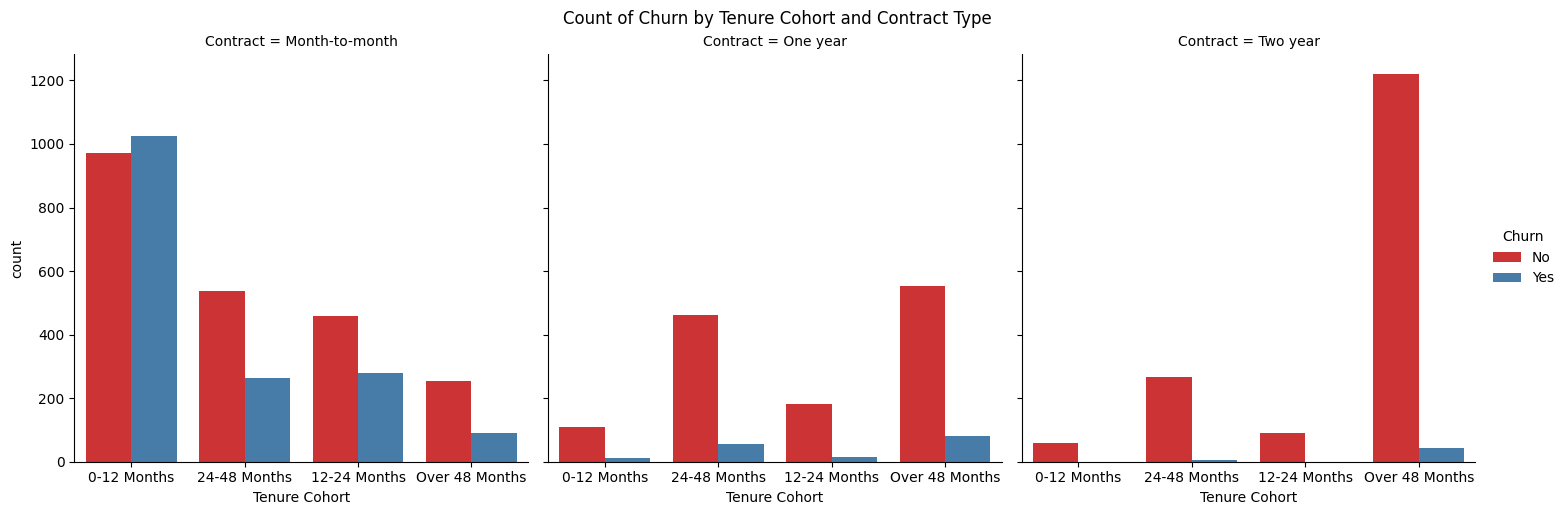

In [56]:
plt.figure(figsize=(10,4), dpi=200)
sns.catplot(data=df, x="Tenure Cohort", hue="Churn", col="Contract", kind="count", palette="Set1")
plt.suptitle("Count of Churn by Tenure Cohort and Contract Type", y=1.02)
plt.show()